Import Libraries

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    BayesianRidge,
    HuberRegressor,
    RANSACRegressor,
    TheilSenRegressor,
    QuantileRegressor
)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor
)

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neural_network import MLPRegressor

from sklearn.isotonic import IsotonicRegression

RANDOM_STATE = 42

Load Dataset

In [7]:
file_path = "../dataset/train_FD001.txt"

df = pd.read_csv(file_path, sep=r"\s+", header=None)

columns = (
    ["engine_id", "cycle"]
    + [f"op{i}" for i in range(1,4)]
    + [f"sensor{i}" for i in range(1,22)]
)

df.columns = columns

df.head()

,engine_id,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


RUL Target

In [8]:
max_cycle = df.groupby("engine_id")["cycle"].transform("max")
df["RUL"] = max_cycle - df["cycle"]

# Remove engine_id
model_df = df.drop(columns=["engine_id"])

model_df.head()

,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,sensor6,...,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21,RUL
0,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,21.61,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,21.61,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,21.61,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,21.61,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,21.61,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [9]:
X = model_df.drop(columns=["RUL"])
y = model_df["RUL"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

X_train.shape, X_test.shape

((16504, 25), (4127, 25))

In [10]:
def evaluate_model(model, name):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    return {"Model": name, "RMSE": rmse, "R2": r2}

In [11]:
model.fit(X_train, y_train)
predictions = model.predict(X_test)
print(predictions[:5])

[105.50979376   8.1415157  197.71216894   2.92323027 116.64259184]


Train Models

In [12]:
results = []

models = [
    (LinearRegression(), "Linear Regression"),
    (Ridge(), "Ridge Regression"),
    (Lasso(), "Lasso Regression"),
    (ElasticNet(), "Elastic Net"),
    (DecisionTreeRegressor(random_state=RANDOM_STATE), "Decision Tree"),
    (RandomForestRegressor(random_state=RANDOM_STATE), "Random Forest"),
    (ExtraTreesRegressor(random_state=RANDOM_STATE), "Extra Trees"),
    (GradientBoostingRegressor(random_state=RANDOM_STATE), "Gradient Boosting"),
    (AdaBoostRegressor(random_state=RANDOM_STATE), "AdaBoost"),
    (KNeighborsRegressor(), "KNN"),
    (SVR(), "SVR"),
]

for model, name in models:
    results.append(evaluate_model(model, name))

results_df = pd.DataFrame(results).sort_values(by="RMSE")
results_df

,Model,RMSE,R2
7,Gradient Boosting,35.613153,0.722400
6,Extra Trees,35.687744,0.721236
5,Random Forest,35.973467,0.716755
0,Linear Regression,39.703044,0.654979
1,Ridge Regression,39.710027,0.654857
9,KNN,39.713798,0.654792
2,Lasso Regression,40.101328,0.648022
8,AdaBoost,40.205563,0.646190
3,Elastic Net,40.280407,0.644871
4,Decision Tree,52.086781,0.406182


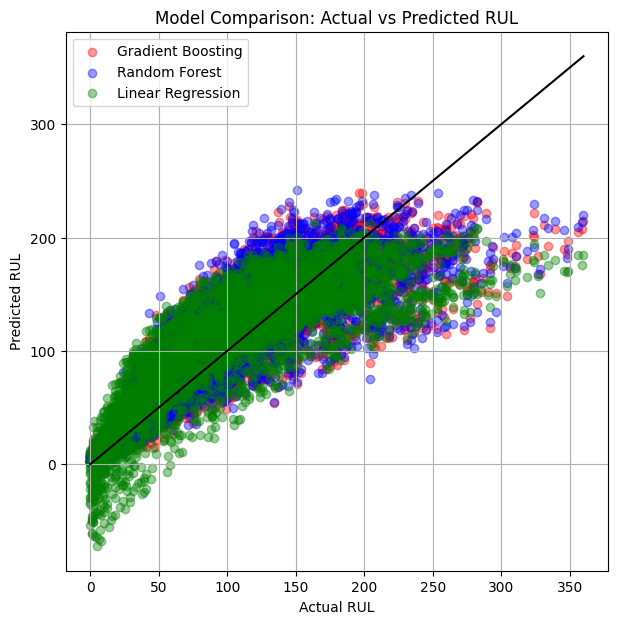

In [23]:
import matplotlib.pyplot as plt

# predictions from models
pred_gb = GradientBoostingRegressor(random_state=42).fit(X_train, y_train).predict(X_test)
pred_rf = RandomForestRegressor(random_state=42).fit(X_train, y_train).predict(X_test)
pred_lr = LinearRegression().fit(X_train, y_train).predict(X_test)

plt.figure(figsize=(7,7))

# Scatter for each model
plt.scatter(y_test, pred_gb, color="red", alpha=0.4, label="Gradient Boosting")
plt.scatter(y_test, pred_rf, color="blue", alpha=0.4, label="Random Forest")
plt.scatter(y_test, pred_lr, color="green", alpha=0.4, label="Linear Regression")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="black"
)

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Model Comparison: Actual vs Predicted RUL")

plt.legend()
plt.grid(True)

plt.show()

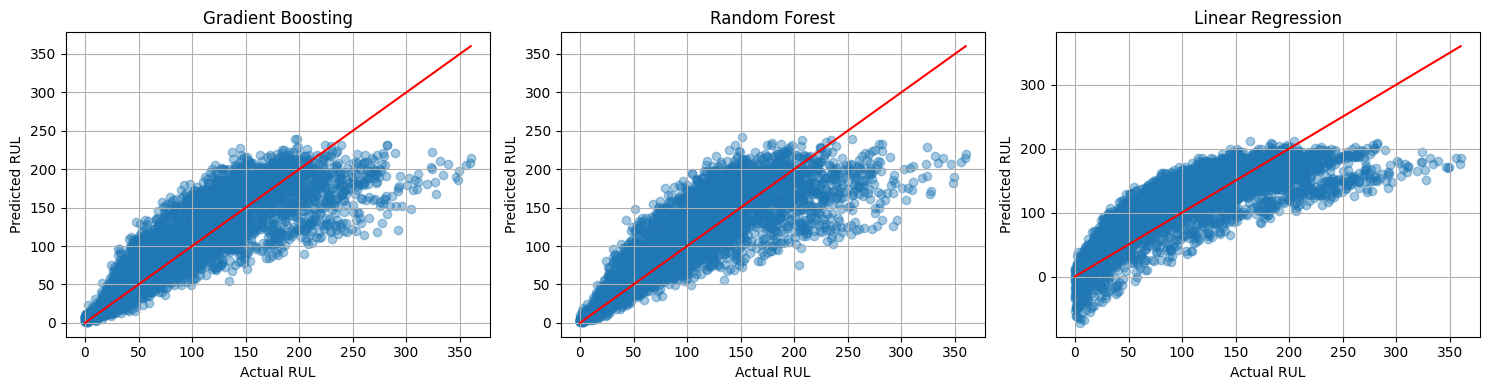

In [24]:
import matplotlib.pyplot as plt

models = {
    "Gradient Boosting": pred_gb,
    "Random Forest": pred_rf,
    "Linear Regression": pred_lr
}

plt.figure(figsize=(15,4))

for i, (name, preds) in enumerate(models.items(), 1):

    plt.subplot(1,3,i)

    plt.scatter(y_test, preds, alpha=0.4)

    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="red"
    )

    plt.xlabel("Actual RUL")
    plt.ylabel("Predicted RUL")
    plt.title(name)

    plt.grid(True)

plt.tight_layout()
plt.show()

In [13]:
from sklearn.ensemble import GradientBoostingRegressor

In [14]:
model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [15]:
model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [16]:
predictions = model.predict(X_test)

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print("RMSE:", rmse)
print("MAE:", mae)
print("R2:", r2)

RMSE: 35.613153166640814
MAE: 25.49302465790262
R2: 0.7224001856372537


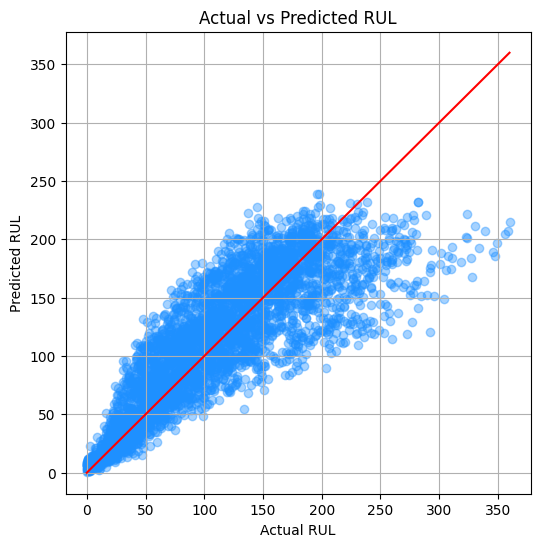

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(y_test, predictions, alpha=0.4, color="dodgerblue")

plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("Actual vs Predicted RUL")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.grid(True)
plt.show()

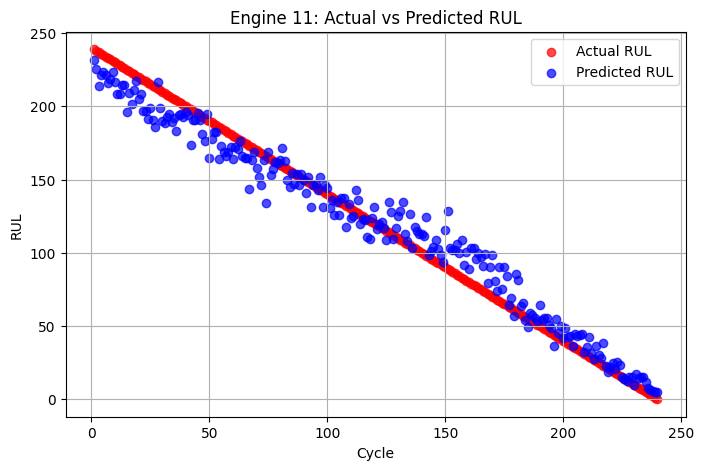

In [25]:
import matplotlib.pyplot as plt

# choose one engine to visualize
engine_id = 11

engine_data = df[df["engine_id"] == engine_id].copy()

# features used for prediction
engine_features = engine_data.drop(columns=["engine_id", "RUL"])

# predicted RUL
predicted_rul = model.predict(engine_features)

plt.figure(figsize=(8,5))

# Actual values (red)
plt.scatter(
    engine_data["cycle"],
    engine_data["RUL"],
    color="red",
    label="Actual RUL",
    alpha=0.7
)

# Predicted values (blue)
plt.scatter(
    engine_data["cycle"],
    predicted_rul,
    color="blue",
    label="Predicted RUL",
    alpha=0.7
)

plt.xlabel("Cycle")
plt.ylabel("RUL")
plt.title(f"Engine {engine_id}: Actual vs Predicted RUL")

plt.legend()
plt.grid(True)

plt.show()